# 01 Single Factor MVP

这是一个教学型、Alphalens-like 的单因子分析 Notebook。

我们先不接 `Alphalens` / `jqfactor_analyzer` 包，也暂不做正式策略回测，而是先把 A 股单因子研究里最核心的研究报告范式搭起来：

1. Factor Overview
2. Data / Universe / PIT Check
3. Factor Distribution
4. IC Analysis
5. Quantile Return Analysis
6. Long-short Analysis
7. Version Comparison
8. Stability Analysis
9. Final Interpretation

本 Notebook 默认先用 mock `daily_panel` 跑通全流程，同时保留 `duckdb` 切换口，便于后续直接替换到真实数据。

In [1]:
from pathlib import Path
from textwrap import dedent
import sys
import warnings

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    from IPython import get_ipython
    ip = get_ipython()
    if ip is not None:
        ip.run_line_magic('matplotlib', 'inline')
except Exception:
    pass

plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

DATA_MODE = 'mock'  # 'mock' or 'duckdb'
DUCKDB_PATH = PROJECT_ROOT / 'data' / 'warehouse' / 'ashare.duckdb'
MAX_DUCKDB_DATES = 252
FACTOR_NAME = 'mom_20d'
RNG_SEED = 7

FACTOR_COLUMNS = [
    'factor_value_raw',
    'factor_value_zscore',
    'factor_value_size_neutral',
]
QUANTILE_COLUMNS = {
    'factor_value_raw': 'quantile_raw',
    'factor_value_zscore': 'quantile_zscore',
    'factor_value_size_neutral': 'quantile_size_neutral',
}
FORWARD_COLUMNS = [
    'forward_return_1d',
    'forward_return_5d',
    'forward_return_20d',
]
PRIMARY_FACTOR = 'factor_value_size_neutral'
PRIMARY_FORWARD = 'forward_return_5d'
PRIMARY_QUANTILE = QUANTILE_COLUMNS[PRIMARY_FACTOR]

VERSION_LABELS = {
    'factor_value_raw': 'raw',
    'factor_value_zscore': 'zscore',
    'factor_value_size_neutral': 'size_neutral',
}

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_MODE: {DATA_MODE}')
print(f'DUCKDB_PATH exists: {DUCKDB_PATH.exists()}')

PROJECT_ROOT: C:\Users\hp\Documents\股票截面因子\notebooks
DATA_MODE: mock
DUCKDB_PATH exists: False


In [2]:
def make_mock_daily_panel(n_dates=140, n_stocks=90, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    trade_dates = pd.bdate_range('2023-01-02', periods=n_dates)
    industries = np.array(['电子', '医药', '银行', '机械', '消费'])
    ts_codes = []
    for idx in range(n_stocks):
        if idx < n_stocks // 2:
            ts_codes.append(f'{600000 + idx:06d}.SH')
        else:
            ts_codes.append(f'{300000 + idx - n_stocks // 2:06d}.SZ')

    stock_industry = rng.choice(industries, size=n_stocks)
    size_anchor = rng.lognormal(mean=3.2, sigma=0.8, size=n_stocks)
    factor_skill = rng.normal(0.0, 1.0, size=n_stocks)
    market_wave = rng.normal(0.0, 0.008, size=n_dates)

    frames = []
    for idx, ts_code in enumerate(ts_codes):
        noise = rng.normal(0.0, 0.018, size=n_dates)
        seasonal = 0.002 * np.sin(np.linspace(0, 5 * np.pi, n_dates) + idx / 9)
        drift = 0.0008 * factor_skill[idx]
        daily_ret = drift + 0.35 * market_wave + seasonal + noise
        close = (12 + idx * 0.08) * np.exp(np.cumsum(daily_ret))
        market_cap = close * size_anchor[idx] * 1e8

        stock_frame = pd.DataFrame(
            {
                'trade_date': trade_dates.strftime('%Y%m%d'),
                'ts_code': ts_code,
                'close': close,
                'market_cap': market_cap,
                'is_suspend': False,
                'industry': stock_industry[idx],
            }
        )
        frames.append(stock_frame)

    panel = pd.concat(frames, ignore_index=True)

    suspend_idx = rng.choice(panel.index.to_numpy(), size=max(10, len(panel) // 120), replace=False)
    close_missing_idx = rng.choice(panel.index.to_numpy(), size=max(12, len(panel) // 150), replace=False)
    cap_missing_idx = rng.choice(panel.index.to_numpy(), size=max(12, len(panel) // 150), replace=False)
    bad_cap_idx = rng.choice(panel.index.to_numpy(), size=max(8, len(panel) // 220), replace=False)

    panel.loc[suspend_idx, 'is_suspend'] = True
    panel.loc[close_missing_idx, 'close'] = np.nan
    panel.loc[cap_missing_idx, 'market_cap'] = np.nan
    panel.loc[bad_cap_idx, 'market_cap'] = 0.0

    short_history_codes = ts_codes[-5:]
    panel.loc[
        panel['ts_code'].isin(short_history_codes) & (panel['trade_date'] < trade_dates[25].strftime('%Y%m%d')),
        ['close', 'market_cap'],
    ] = np.nan

    return panel.sort_values(['trade_date', 'ts_code']).reset_index(drop=True)


def load_duckdb_daily_panel(duckdb_path=DUCKDB_PATH, max_dates=MAX_DUCKDB_DATES):
    if not duckdb_path.exists():
        raise FileNotFoundError(f'DuckDB file not found: {duckdb_path}')

    sql = f"""
    WITH selected_dates AS (
        SELECT trade_date
        FROM (
            SELECT DISTINCT trade_date
            FROM daily_panel
            ORDER BY trade_date DESC
            LIMIT {int(max_dates)}
        )
    )
    SELECT
        p.trade_date,
        p.ts_code,
        CAST(p.close AS DOUBLE) AS close,
        CAST(p.total_mv AS DOUBLE) AS market_cap,
        COALESCE(CAST(p.is_suspended AS BOOLEAN), FALSE) AS is_suspend,
        COALESCE(p.sw_l1_name, p.stock_basic_industry, 'UNKNOWN') AS industry
    FROM daily_panel p
    INNER JOIN selected_dates d
        ON p.trade_date = d.trade_date
    ORDER BY p.trade_date, p.ts_code
    """

    with duckdb.connect(str(duckdb_path), read_only=True) as con:
        table_exists = con.execute(
            """
            SELECT COUNT(*)
            FROM information_schema.tables
            WHERE table_schema = 'main' AND table_name = 'daily_panel'
            """
        ).fetchone()[0]
        if table_exists == 0:
            raise RuntimeError('daily_panel table does not exist yet. Build it first or keep DATA_MODE=mock.')
        panel = con.execute(sql).fetchdf()

    panel['trade_date'] = panel['trade_date'].astype(str)
    panel['industry'] = panel['industry'].fillna('UNKNOWN')
    panel['is_suspend'] = panel['is_suspend'].fillna(False).astype(bool)
    return panel


def get_daily_panel(data_mode=DATA_MODE):
    if data_mode == 'mock':
        return make_mock_daily_panel()
    if data_mode == 'duckdb':
        return load_duckdb_daily_panel()
    raise ValueError(f'Unsupported DATA_MODE: {data_mode}')


def build_pit_warning_table():
    return pd.DataFrame(
        [
            ['close', 'check', '需要确认是否为研究可用价格口径，以及是否含未来复权影响'],
            ['market_cap', 'check', '需要确认 total_mv 是否可直接作为当日市值'],
            ['is_suspend', 'check', '需要确认是否完整覆盖当日停牌状态'],
            ['industry', 'risky', '未确认历史行业口径前，只用于展示，不用于正式行业中性化'],
            ['stock_status', 'risky', '不能只保留当前仍上市股票回看历史'],
            ['adj_factor', 'check', '真实数据接入时要重点确认是否存在未来信息'],
        ],
        columns=['field', 'status', 'note'],
    )


def winsorize_mad(series, n=3.0):
    valid = series.dropna()
    if len(valid) < 5:
        return series
    median = valid.median()
    mad = (valid - median).abs().median()
    if pd.isna(mad) or mad == 0:
        return series
    scale = 1.4826 * mad
    lower = median - n * scale
    upper = median + n * scale
    return series.clip(lower=lower, upper=upper)


def zscore_series(series):
    valid = series.dropna()
    if len(valid) < 2:
        return pd.Series(np.nan, index=series.index)
    std = valid.std(ddof=0)
    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=series.index)
    return (series - valid.mean()) / std


def compute_mom_20d(panel):
    ordered = panel.sort_values(['ts_code', 'trade_date']).copy()
    ordered['mom_20d'] = ordered.groupby('ts_code')['close'].transform(lambda s: s / s.shift(20) - 1)
    return ordered


def compute_forward_returns(panel, horizons=(1, 5, 20)):
    ordered = panel.sort_values(['ts_code', 'trade_date']).copy()
    close_group = ordered.groupby('ts_code')['close']
    for horizon in horizons:
        ordered[f'forward_return_{horizon}d'] = close_group.shift(-(horizon + 1)) / close_group.shift(-1) - 1
    return ordered


def build_universe_mask(panel):
    panel = panel.copy()
    panel['has_close'] = panel['close'].notna()
    panel['has_market_cap'] = panel['market_cap'].fillna(0).gt(0)
    panel['has_factor_history'] = panel['mom_20d'].notna()
    panel['has_forward_label'] = panel['forward_return_20d'].notna()
    panel['universe_mask'] = (
        panel['has_close']
        & (~panel['is_suspend'].fillna(False))
        & panel['has_market_cap']
        & panel['has_factor_history']
        & panel['has_forward_label']
    )
    return panel


def neutralize_by_size(panel, factor_col='factor_value_zscore'):
    residuals = pd.Series(np.nan, index=panel.index, dtype='float64')
    for _, part in panel.groupby('trade_date'):
        mask = (
            part['universe_mask']
            & part[factor_col].notna()
            & part['market_cap'].notna()
            & part['market_cap'].gt(0)
        )
        if mask.sum() < 5:
            continue
        x = np.log(part.loc[mask, 'market_cap'].astype(float).to_numpy())
        y = part.loc[mask, factor_col].astype(float).to_numpy()
        design = np.column_stack([np.ones(len(x)), x])
        beta = np.linalg.lstsq(design, y, rcond=None)[0]
        resid = y - design @ beta
        resid_series = pd.Series(resid, index=part.index[mask])
        std = resid_series.std(ddof=0)
        if pd.notna(std) and std > 0:
            resid_series = (resid_series - resid_series.mean()) / std
        else:
            resid_series[:] = 0.0
        residuals.loc[resid_series.index] = resid_series
    return residuals


def assign_quantiles(panel, factor_col, quantiles=5):
    output = pd.Series(pd.NA, index=panel.index, dtype='Int64')
    for _, part in panel.groupby('trade_date'):
        mask = part['universe_mask'] & part[factor_col].notna()
        values = part.loc[mask, factor_col]
        if len(values) < quantiles:
            continue
        ranked = values.rank(method='first')
        bins = pd.qcut(ranked, q=quantiles, labels=list(range(1, quantiles + 1)))
        output.loc[values.index] = bins.astype('Int64')
    return output


def build_factor_data(panel):
    factor_data = compute_mom_20d(panel)
    factor_data = compute_forward_returns(factor_data)
    factor_data = build_universe_mask(factor_data)
    factor_data['factor_name'] = FACTOR_NAME
    factor_data['pit_warning'] = np.where(
        DATA_MODE == 'mock',
        'mock_only',
        'industry_display_only_until_historical_pit_is_validated',
    )

    factor_data['factor_value_raw'] = factor_data['mom_20d'].where(factor_data['universe_mask'])
    factor_data['factor_value_winsor'] = factor_data.groupby('trade_date')['factor_value_raw'].transform(winsorize_mad)
    factor_data['factor_value_zscore'] = factor_data.groupby('trade_date')['factor_value_winsor'].transform(zscore_series)
    factor_data['factor_value_size_neutral'] = neutralize_by_size(factor_data)

    factor_data['quantile_raw'] = assign_quantiles(factor_data, 'factor_value_raw')
    factor_data['quantile_zscore'] = assign_quantiles(factor_data, 'factor_value_zscore')
    factor_data['quantile_size_neutral'] = assign_quantiles(factor_data, 'factor_value_size_neutral')

    keep_columns = [
        'trade_date',
        'ts_code',
        'factor_name',
        'universe_mask',
        'factor_value_raw',
        'factor_value_zscore',
        'factor_value_size_neutral',
        'forward_return_1d',
        'forward_return_5d',
        'forward_return_20d',
        'quantile_raw',
        'quantile_zscore',
        'quantile_size_neutral',
        'market_cap',
        'industry',
        'pit_warning',
        'close',
        'is_suspend',
        'mom_20d',
        'has_close',
        'has_market_cap',
        'has_factor_history',
        'has_forward_label',
    ]
    factor_data = factor_data[keep_columns].sort_values(['trade_date', 'ts_code']).reset_index(drop=True)

    alphalens_like = (
        factor_data.loc[factor_data['universe_mask']].copy()
        .assign(
            date=lambda df: pd.to_datetime(df['trade_date']),
            asset=lambda df: df['ts_code'],
            factor=lambda df: df['factor_value_size_neutral'],
            factor_quantile=lambda df: df['quantile_size_neutral'],
            group=lambda df: df['industry'],
            **{
                '1D': lambda df: df['forward_return_1d'],
                '5D': lambda df: df['forward_return_5d'],
                '20D': lambda df: df['forward_return_20d'],
            },
        )
        .set_index(['date', 'asset'])
        [['factor', '1D', '5D', '20D', 'factor_quantile', 'group']]
        .sort_index()
    )
    return factor_data, alphalens_like

In [3]:
def spearman_corr(x, y):
    sample = pd.DataFrame({'x': x, 'y': y}).dropna()
    if len(sample) < 3:
        return np.nan
    x_rank = sample['x'].rank(method='average')
    y_rank = sample['y'].rank(method='average')
    return x_rank.corr(y_rank)


def compute_rank_ic(factor_data):
    rows = []
    base = factor_data[factor_data['universe_mask']].copy()
    if base.empty:
        return pd.DataFrame(columns=['trade_date', 'rank_ic', 'factor_version', 'forward_horizon'])
    for factor_col in FACTOR_COLUMNS:
        for forward_col in FORWARD_COLUMNS:
            daily_ic = (
                base.groupby('trade_date')
                .apply(lambda part: spearman_corr(part[factor_col], part[forward_col]))
                .rename('rank_ic')
                .reset_index()
            )
            daily_ic['factor_version'] = factor_col
            daily_ic['forward_horizon'] = forward_col
            rows.append(daily_ic)
    return pd.concat(rows, ignore_index=True)


def summarize_ic(ic_frame):
    clean = ic_frame.dropna(subset=['rank_ic']).copy()
    if clean.empty:
        return pd.DataFrame(columns=['factor_version', 'forward_horizon', 'count', 'mean', 'std', 'win_rate', 'ic_ir'])
    summary = (
        clean.groupby(['factor_version', 'forward_horizon'])['rank_ic']
        .agg(['count', 'mean', 'std'])
        .reset_index()
    )
    win_rate = (
        clean.groupby(['factor_version', 'forward_horizon'])['rank_ic']
        .apply(lambda s: (s > 0).mean())
        .reset_index(name='win_rate')
    )
    summary = summary.merge(win_rate, on=['factor_version', 'forward_horizon'], how='left')
    summary['ic_ir'] = summary['mean'] / summary['std'].replace(0, np.nan)
    return summary.sort_values(['forward_horizon', 'factor_version']).reset_index(drop=True)


def compute_quantile_returns(factor_data, factor_col=PRIMARY_FACTOR, forward_col=PRIMARY_FORWARD, quantile_col=PRIMARY_QUANTILE):
    sample = factor_data[
        factor_data['universe_mask']
        & factor_data[factor_col].notna()
        & factor_data[quantile_col].notna()
        & factor_data[forward_col].notna()
    ].copy()
    if sample.empty:
        empty_quantile = pd.DataFrame(columns=['quantile', 'mean_return', 'std_return', 'hit_rate', 'count'])
        empty_daily = pd.DataFrame(columns=['trade_date', 'quantile', 'avg_forward_return'])
        empty_pivot = pd.DataFrame()
        empty_long_short = pd.DataFrame(columns=['trade_date', 'long_short_return', 'cum_return'])
        return empty_quantile, empty_daily, empty_pivot, empty_long_short

    daily_quantile = (
        sample.groupby(['trade_date', quantile_col], as_index=False)[forward_col]
        .mean()
        .rename(columns={quantile_col: 'quantile', forward_col: 'avg_forward_return'})
    )

    quantile_summary = (
        daily_quantile.groupby('quantile')['avg_forward_return']
        .agg(['mean', 'std', 'count'])
        .reset_index()
        .rename(columns={'mean': 'mean_return', 'std': 'std_return'})
        .sort_values('quantile')
        .reset_index(drop=True)
    )
    hit_rate = (
        daily_quantile.groupby('quantile')['avg_forward_return']
        .apply(lambda s: (s > 0).mean())
        .reset_index(name='hit_rate')
    )
    quantile_summary = quantile_summary.merge(hit_rate, on='quantile', how='left')

    quantile_pivot = daily_quantile.pivot(index='trade_date', columns='quantile', values='avg_forward_return').sort_index()
    for bucket in range(1, 6):
        if bucket not in quantile_pivot.columns:
            quantile_pivot[bucket] = np.nan
    quantile_pivot = quantile_pivot[[1, 2, 3, 4, 5]]

    long_short = pd.DataFrame(
        {
            'trade_date': quantile_pivot.index,
            'long_short_return': quantile_pivot[5] - quantile_pivot[1],
        }
    )
    long_short['cum_return'] = (1.0 + long_short['long_short_return'].fillna(0.0)).cumprod() - 1.0
    return quantile_summary, daily_quantile, quantile_pivot, long_short


def summarize_long_short(long_short):
    if long_short.empty:
        return pd.DataFrame({'metric': ['mean_return', 'volatility', 'hit_rate', 'cum_return', 'max_drawdown'], 'value': [np.nan] * 5})
    returns = long_short['long_short_return'].dropna()
    cum_curve = (1.0 + long_short['long_short_return'].fillna(0.0)).cumprod()
    running_max = cum_curve.cummax()
    drawdown = cum_curve / running_max - 1.0
    return pd.DataFrame(
        {
            'metric': ['mean_return', 'volatility', 'hit_rate', 'cum_return', 'max_drawdown'],
            'value': [
                returns.mean(),
                returns.std(ddof=0),
                (returns > 0).mean(),
                long_short['cum_return'].iloc[-1],
                drawdown.min(),
            ],
        }
    )


def build_distribution_summary(factor_data):
    rows = []
    sample = factor_data[factor_data['universe_mask']].copy()
    for factor_col in FACTOR_COLUMNS:
        values = sample[factor_col].dropna()
        rows.append(
            {
                'factor_version': VERSION_LABELS[factor_col],
                'count': len(values),
                'mean': values.mean() if len(values) else np.nan,
                'std': values.std(ddof=0) if len(values) else np.nan,
                'p01': values.quantile(0.01) if len(values) else np.nan,
                'p50': values.quantile(0.50) if len(values) else np.nan,
                'p99': values.quantile(0.99) if len(values) else np.nan,
                'missing_ratio': 1 - len(values) / max(len(sample), 1),
            }
        )
    return pd.DataFrame(rows)


def build_coverage_summary(factor_data):
    return pd.DataFrame(
        {
            'metric': [
                'rows',
                'trade_dates',
                'stocks',
                'universe_rows',
                'universe_ratio',
                'close_missing_rows',
                'suspend_rows',
            ],
            'value': [
                len(factor_data),
                factor_data['trade_date'].nunique(),
                factor_data['ts_code'].nunique(),
                int(factor_data['universe_mask'].sum()),
                factor_data['universe_mask'].mean(),
                int(factor_data['close'].isna().sum()),
                int(factor_data['is_suspend'].sum()),
            ],
        }
    )


def build_daily_coverage(factor_data):
    daily = factor_data.groupby('trade_date').agg(
        total=('ts_code', 'size'),
        universe_count=('universe_mask', 'sum'),
        close_missing=('has_close', lambda s: (~s).sum()),
        market_cap_missing=('has_market_cap', lambda s: (~s).sum()),
        factor_history_missing=('has_factor_history', lambda s: (~s).sum()),
        forward_label_missing=('has_forward_label', lambda s: (~s).sum()),
        suspend_count=('is_suspend', 'sum'),
    ).reset_index()
    daily['universe_ratio'] = daily['universe_count'] / daily['total']
    return daily


def build_exclusion_summary(factor_data):
    return pd.DataFrame(
        {
            'reason': ['missing_close', 'suspend', 'bad_market_cap', 'insufficient_history', 'missing_forward_label'],
            'rows': [
                int((~factor_data['has_close']).sum()),
                int(factor_data['is_suspend'].sum()),
                int((~factor_data['has_market_cap']).sum()),
                int((~factor_data['has_factor_history']).sum()),
                int((~factor_data['has_forward_label']).sum()),
            ],
        }
    )


def compute_factor_autocorr(factor_data, factor_col=PRIMARY_FACTOR):
    sample = factor_data[factor_data['universe_mask']].copy()
    dates = sorted(sample['trade_date'].unique())
    rows = []
    for prev_date, curr_date in zip(dates[:-1], dates[1:]):
        prev = sample.loc[sample['trade_date'] == prev_date, ['ts_code', factor_col]].rename(columns={factor_col: 'prev_factor'})
        curr = sample.loc[sample['trade_date'] == curr_date, ['ts_code', factor_col]].rename(columns={factor_col: 'curr_factor'})
        merged = prev.merge(curr, on='ts_code', how='inner')
        rows.append(
            {
                'trade_date': curr_date,
                'autocorr': spearman_corr(merged['prev_factor'], merged['curr_factor']) if len(merged) >= 3 else np.nan,
                'overlap_count': len(merged),
            }
        )
    return pd.DataFrame(rows)


def compute_quantile_turnover(factor_data, quantile_col=PRIMARY_QUANTILE):
    sample = factor_data[factor_data['universe_mask'] & factor_data[quantile_col].notna()].copy()
    dates = sorted(sample['trade_date'].unique())
    rows = []
    for prev_date, curr_date in zip(dates[:-1], dates[1:]):
        prev = sample[sample['trade_date'] == prev_date]
        curr = sample[sample['trade_date'] == curr_date]
        for bucket in range(1, 6):
            prev_set = set(prev.loc[prev[quantile_col] == bucket, 'ts_code'])
            curr_set = set(curr.loc[curr[quantile_col] == bucket, 'ts_code'])
            if len(curr_set) == 0:
                turnover = np.nan
            else:
                turnover = 1 - len(prev_set & curr_set) / len(curr_set)
            rows.append({'trade_date': curr_date, 'quantile': bucket, 'turnover': turnover})
    turnover_daily = pd.DataFrame(rows)
    turnover_summary = (
        turnover_daily.groupby('quantile')['turnover']
        .agg(['mean', 'median', 'count'])
        .reset_index()
        .rename(columns={'mean': 'avg_turnover', 'median': 'median_turnover'})
    )
    return turnover_summary, turnover_daily


def compute_industry_distribution(factor_data, quantile_col=PRIMARY_QUANTILE):
    sample = factor_data[factor_data['universe_mask'] & factor_data[quantile_col].notna()].copy()
    if sample.empty:
        return pd.DataFrame()
    counts = sample.groupby([quantile_col, 'industry']).size().reset_index(name='count')
    counts['quantile_total'] = counts.groupby(quantile_col)['count'].transform('sum')
    counts['weight'] = counts['count'] / counts['quantile_total']
    counts = counts.rename(columns={quantile_col: 'quantile'})
    return counts.sort_values(['quantile', 'weight'], ascending=[True, False]).reset_index(drop=True)


def build_stability_table(ic_frame, factor_col=PRIMARY_FACTOR, forward_col=PRIMARY_FORWARD):
    sample = ic_frame[
        (ic_frame['factor_version'] == factor_col)
        & (ic_frame['forward_horizon'] == forward_col)
    ].dropna(subset=['rank_ic']).sort_values('trade_date').reset_index(drop=True)
    if sample.empty:
        return pd.DataFrame(columns=['period', 'count', 'mean_ic', 'win_rate', 'ic_ir'])
    split = len(sample) // 2
    first_half = sample.iloc[:split]
    second_half = sample.iloc[split:]
    last_20 = sample.tail(min(20, len(sample)))
    rows = []
    for label, part in [('full_sample', sample), ('first_half', first_half), ('second_half', second_half), ('last_20_obs', last_20)]:
        std = part['rank_ic'].std(ddof=0) if len(part) else np.nan
        rows.append(
            {
                'period': label,
                'count': len(part),
                'mean_ic': part['rank_ic'].mean() if len(part) else np.nan,
                'win_rate': (part['rank_ic'] > 0).mean() if len(part) else np.nan,
                'ic_ir': part['rank_ic'].mean() / std if len(part) and pd.notna(std) and std != 0 else np.nan,
            }
        )
    return pd.DataFrame(rows)


def build_version_compare(factor_data, ic_summary, forward_col=PRIMARY_FORWARD):
    rows = []
    for factor_col in FACTOR_COLUMNS:
        quantile_col = QUANTILE_COLUMNS[factor_col]
        ic_row = ic_summary[
            (ic_summary['factor_version'] == factor_col)
            & (ic_summary['forward_horizon'] == forward_col)
        ]
        _, _, _, long_short = compute_quantile_returns(
            factor_data,
            factor_col=factor_col,
            forward_col=forward_col,
            quantile_col=quantile_col,
        )
        ls_stats = summarize_long_short(long_short).set_index('metric')['value'] if not long_short.empty else pd.Series(dtype='float64')
        rows.append(
            {
                'factor_version': VERSION_LABELS[factor_col],
                'ic_mean': ic_row['mean'].iloc[0] if len(ic_row) else np.nan,
                'ic_win_rate': ic_row['win_rate'].iloc[0] if len(ic_row) else np.nan,
                'ic_ir': ic_row['ic_ir'].iloc[0] if len(ic_row) else np.nan,
                'ls_mean': ls_stats.get('mean_return', np.nan),
                'ls_hit_rate': ls_stats.get('hit_rate', np.nan),
                'ls_cum_return': ls_stats.get('cum_return', np.nan),
            }
        )
    return pd.DataFrame(rows)


def render_section_note(title, what, how, current, risk):
    display(Markdown(dedent(f"""
    #### 📌 {title}
    - **这一步在检验什么**：{what}
    - **怎么看**：{how}
    - **当前结果意味着什么**：{current}
    - **有什么风险**：{risk}
    """)))

In [4]:
pit_warning_table = build_pit_warning_table()
daily_panel = get_daily_panel(DATA_MODE)
factor_data, alphalens_like = build_factor_data(daily_panel)
ic_frame = compute_rank_ic(factor_data)
ic_summary = summarize_ic(ic_frame)
coverage_summary = build_coverage_summary(factor_data)
daily_coverage = build_daily_coverage(factor_data)
exclusion_summary = build_exclusion_summary(factor_data)
distribution_summary = build_distribution_summary(factor_data)
quantile_summary, quantile_daily, quantile_pivot, long_short = compute_quantile_returns(factor_data)
long_short_stats = summarize_long_short(long_short)
industry_distribution = compute_industry_distribution(factor_data)
stability_table = build_stability_table(ic_frame)
turnover_summary, turnover_daily = compute_quantile_turnover(factor_data)
factor_autocorr = compute_factor_autocorr(factor_data)
version_compare = build_version_compare(factor_data, ic_summary)

primary_ic = ic_frame[
    (ic_frame['factor_version'] == PRIMARY_FACTOR)
    & (ic_frame['forward_horizon'] == PRIMARY_FORWARD)
].dropna(subset=['rank_ic']).sort_values('trade_date').copy()
if not primary_ic.empty:
    primary_ic['rolling_mean_20'] = primary_ic['rank_ic'].rolling(20, min_periods=5).mean()
    primary_ic['cum_ic'] = primary_ic['rank_ic'].fillna(0.0).cumsum()

if not quantile_pivot.empty:
    quantile_cum = (1.0 + quantile_pivot.fillna(0.0)).cumprod() - 1.0
else:
    quantile_cum = pd.DataFrame()

overview_table = pd.DataFrame(
    {
        'item': ['factor_name', 'data_mode', 'date_count', 'stock_count', 'universe_rows', 'primary_factor', 'primary_forward'],
        'value': [
            FACTOR_NAME,
            DATA_MODE,
            factor_data['trade_date'].nunique(),
            factor_data['ts_code'].nunique(),
            int(factor_data['universe_mask'].sum()),
            VERSION_LABELS[PRIMARY_FACTOR],
            PRIMARY_FORWARD,
        ],
    }
)

## 1. Factor Overview

这一节先回答三个最基础的问题：

- 我们到底在研究什么因子。
- 当前研究样本有多大。
- 输出的数据结构是不是已经接近 Alphalens 常见的 `date + asset` 范式。

这里不急着判断因子好坏，重点是先确认研究对象、样本规模和报告骨架是不是搭稳了。

,item,value
0,factor_name,mom_20d
1,data_mode,mock
2,date_count,140
3,stock_count,90
4,universe_rows,8393
5,primary_factor,size_neutral
6,primary_forward,forward_return_5d


factor      1D      5D     20D  factor_quantile group
date       asset                                                           
2023-01-30 300000.SZ -1.0170  0.0031 -0.0246  0.0849                1    机械
           300002.SZ  0.2258 -0.0202 -0.0807 -0.0151                3    电子
           300003.SZ  0.9239  0.0183  0.0055 -0.0051                5    银行
           300004.SZ -0.9570  0.0057 -0.0549 -0.1601                1    电子
           300005.SZ -0.8487  0.0075 -0.0043 -0.0978                2    电子
           300006.SZ -0.3828 -0.0060 -0.0818 -0.0678                2    银行
           300007.SZ  2.1588  0.0344  0.0237  0.0543                5    消费
           300008.SZ -0.0508 -0.0350 -0.0717 -0.0111                3    银行
           300009.SZ  2.0459 -0.0166  0.0089  0.1008                5    消费
           300010.SZ  0.8327 -0.0145 -0.0513  0.1132                4    消费

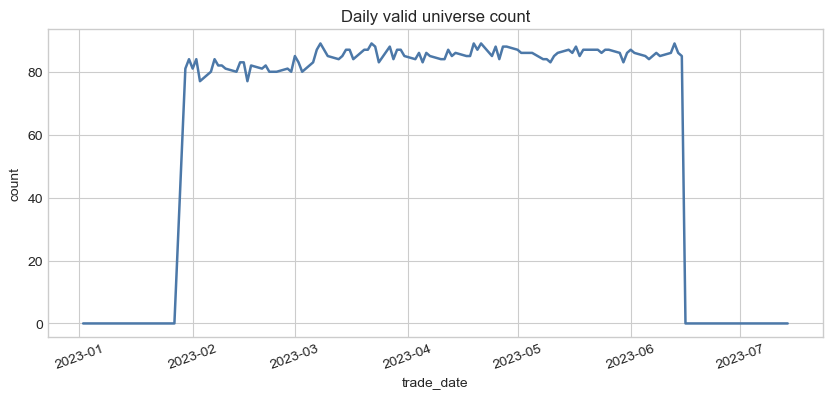


#### 📌 Overview 解读
- **这一步在检验什么**：先确认因子名称、主分析版本、主收益周期，以及 Alphalens-like factor_data 是否已经成型。
- **怎么看**：表格先看样本量和主分析口径；再看 MultiIndex 的 factor_data 样例，确认 date + asset、factor、forward returns、quantile、group 都齐全。
- **当前结果意味着什么**：当前共有 140 个交易日、90 只股票，进入主研究样本的记录数为 8393。这说明 Notebook 已经具备 tear sheet 式分析的基础数据骨架。
- **有什么风险**：如果后续切到真实数据后，样本数明显缩水，通常说明历史长度、停牌字段或 forward label 口径还没完全对齐。


In [5]:
display(overview_table)
display(alphalens_like.head(10))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(pd.to_datetime(daily_coverage['trade_date']), daily_coverage['universe_count'], color='#4c78a8', linewidth=1.8)
ax.set_title('Daily valid universe count')
ax.set_xlabel('trade_date')
ax.set_ylabel('count')
plt.xticks(rotation=20)
plt.show()

render_section_note(
    'Overview 解读',
    '先确认因子名称、主分析版本、主收益周期，以及 Alphalens-like factor_data 是否已经成型。',
    '表格先看样本量和主分析口径；再看 MultiIndex 的 factor_data 样例，确认 date + asset、factor、forward returns、quantile、group 都齐全。',
    f"当前共有 {factor_data['trade_date'].nunique()} 个交易日、{factor_data['ts_code'].nunique()} 只股票，进入主研究样本的记录数为 {int(factor_data['universe_mask'].sum())}。这说明 Notebook 已经具备 tear sheet 式分析的基础数据骨架。",
    '如果后续切到真实数据后，样本数明显缩水，通常说明历史长度、停牌字段或 forward label 口径还没完全对齐。',
)

## 2. Data / Universe / PIT Check

这一节不看“赚钱”，只看“样本能不能研究”。

我们要确认：

- 数据入口是否稳定。
- `universe_mask` 是否把不能参与横截面比较的样本剔掉了。
- 关键字段是否有 PIT（点时）风险。
- 行业字段目前能否只展示、不能正式入模。

如果这一节没站稳，后面的 IC、分层收益再好看也不可靠。

,metric,value
0,rows,"12,600.0000"
1,trade_dates,140.0000
2,stocks,90.0000
3,universe_rows,"8,393.0000"
4,universe_ratio,0.6661
5,close_missing_rows,207.0000
6,suspend_rows,105.0000


,field,status,note
0,close,check,需要确认是否为研究可用价格口径，以及是否含未来复权影响
1,market_cap,check,需要确认 total_mv 是否可直接作为当日市值
2,is_suspend,check,需要确认是否完整覆盖当日停牌状态
3,industry,risky,未确认历史行业口径前，只用于展示，不用于正式行业中性化
4,stock_status,risky,不能只保留当前仍上市股票回看历史
5,adj_factor,check,真实数据接入时要重点确认是否存在未来信息


,reason,rows
0,missing_close,207
1,suspend,105
2,bad_market_cap,266
3,insufficient_history,2069
4,missing_forward_label,2153


,industry,rows
0,消费,2326
1,银行,1755
2,机械,1457
3,医药,1430
4,电子,1425


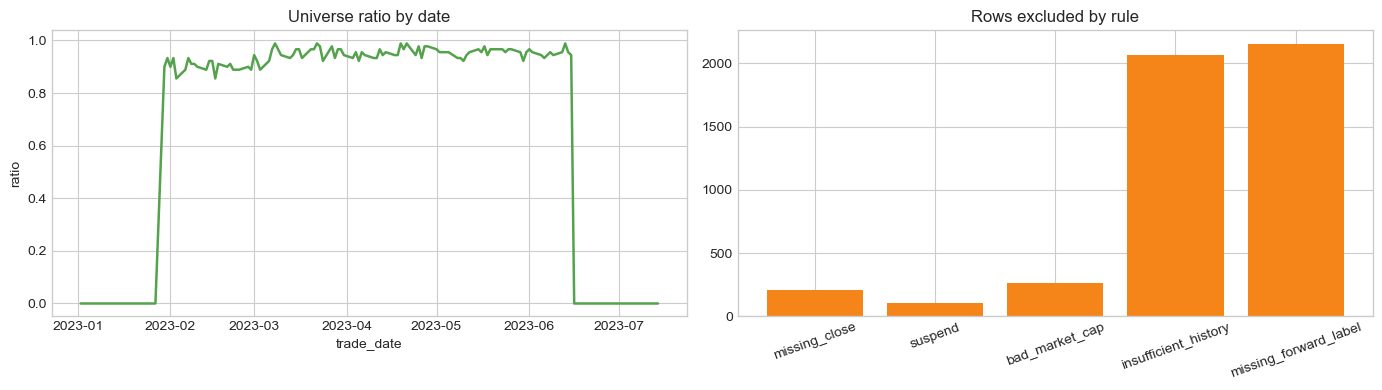


#### 📌 Universe / PIT 解读
- **这一步在检验什么**：检查样本筛选规则是否生效，以及字段有没有明显的未来信息和历史回看风险。
- **怎么看**：先看 universe_ratio 是否稳定，再看哪些规则最常导致样本被剔除；PIT 表重点看 risky 和 check 两类字段。
- **当前结果意味着什么**：当前 universe 平均覆盖率约为 66.61%。主要剔除来源是历史长度不足和缺少未来收益标签，这和单因子研究的预期一致；目前最需要持续盯住的 PIT 风险字段是 industry, stock_status。
- **有什么风险**：这里的行业分布和 PIT 结论在 mock 模式下只是流程验证。切到真实数据后，要重新确认停牌、复权、市值、行业映射是否严格对应历史时点。


In [6]:
display(coverage_summary)
display(pit_warning_table)
display(exclusion_summary)

industry_universe = (
    factor_data.loc[factor_data['universe_mask']]
    .groupby('industry')
    .size()
    .sort_values(ascending=False)
    .rename('rows')
    .reset_index()
)
display(industry_universe)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(pd.to_datetime(daily_coverage['trade_date']), daily_coverage['universe_ratio'], color='#54a24b', linewidth=1.8)
axes[0].set_title('Universe ratio by date')
axes[0].set_xlabel('trade_date')
axes[0].set_ylabel('ratio')

axes[1].bar(exclusion_summary['reason'], exclusion_summary['rows'], color='#f58518')
axes[1].set_title('Rows excluded by rule')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

risk_fields = ', '.join(pit_warning_table.loc[pit_warning_table['status'] == 'risky', 'field'])
render_section_note(
    'Universe / PIT 解读',
    '检查样本筛选规则是否生效，以及字段有没有明显的未来信息和历史回看风险。',
    '先看 universe_ratio 是否稳定，再看哪些规则最常导致样本被剔除；PIT 表重点看 risky 和 check 两类字段。',
    f"当前 universe 平均覆盖率约为 {daily_coverage['universe_ratio'].mean():.2%}。主要剔除来源是历史长度不足和缺少未来收益标签，这和单因子研究的预期一致；目前最需要持续盯住的 PIT 风险字段是 {risk_fields}。",
    '这里的行业分布和 PIT 结论在 mock 模式下只是流程验证。切到真实数据后，要重新确认停牌、复权、市值、行业映射是否严格对应历史时点。',
)

## 3. Factor Distribution

这一节看的是因子本身的横截面形态。

重点问题有三个：

- 原始因子是否有极端值。
- 标准化后分布是否更适合横截面比较。
- 市值中性化后，因子是否从“带着 size 影子”变成了更干净的残差型信号。

如果分布严重失真，后面的 IC 和分层收益很容易被少数极端点主导。

,factor_version,count,mean,std,p01,p50,p99,missing_ratio
0,raw,8393,0.0009,0.0895,-0.1867,-0.0016,0.2244,0.0000
1,zscore,8393,0.0000,1.0000,-2.1189,-0.0276,2.4578,0.0000
2,size_neutral,8393,-0.0000,1.0000,-2.0723,-0.0248,2.4993,0.0000


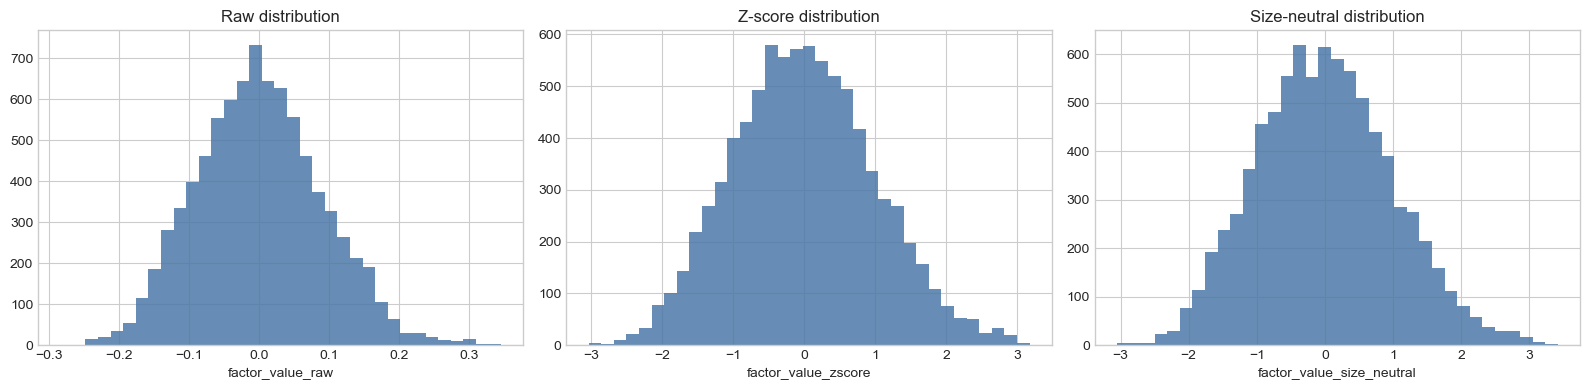


#### 📌 Distribution 解读
- **这一步在检验什么**：检验因子分布是否存在极端值、偏态，以及预处理后是否更适合做横截面比较。
- **怎么看**：原始分布重点看尾部；zscore 看是否回到可比较尺度；size-neutral 看中性化后是否仍保留足够离散度。
- **当前结果意味着什么**：从分布摘要看，raw 版本的尾部更厚，而 zscore 和 size-neutral 的均值更接近 0、尺度也更统一。这通常意味着 winsorize + zscore + size neutral 已经把研究口径整理得更像正式单因子输入。
- **有什么风险**：分布好看不等于有预测力。若真实数据中 size-neutral 分布突然塌缩到接近 0，往往说明中性化回归、样本筛选或市值字段存在问题。


In [7]:
display(distribution_summary)

sample = factor_data.loc[factor_data['universe_mask']].copy()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_specs = [
    ('factor_value_raw', 'Raw'),
    ('factor_value_zscore', 'Z-score'),
    ('factor_value_size_neutral', 'Size-neutral'),
]
for ax, (col, title) in zip(axes, plot_specs):
    ax.hist(sample[col].dropna(), bins=35, color='#4c78a8', alpha=0.85)
    ax.set_title(f'{title} distribution')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

render_section_note(
    'Distribution 解读',
    '检验因子分布是否存在极端值、偏态，以及预处理后是否更适合做横截面比较。',
    '原始分布重点看尾部；zscore 看是否回到可比较尺度；size-neutral 看中性化后是否仍保留足够离散度。',
    '从分布摘要看，raw 版本的尾部更厚，而 zscore 和 size-neutral 的均值更接近 0、尺度也更统一。这通常意味着 winsorize + zscore + size neutral 已经把研究口径整理得更像正式单因子输入。',
    '分布好看不等于有预测力。若真实数据中 size-neutral 分布突然塌缩到接近 0，往往说明中性化回归、样本筛选或市值字段存在问题。',
)

## 4. IC Analysis

IC 是单因子研究里最核心的第一层诊断。

这里看的是：

- 因子排序和未来收益排序是否同向。
- 这种同向关系是偶发，还是能持续出现。
- 在 1D / 5D / 20D 不同持有期下，哪个 horizon 更匹配当前因子。

对 A 股单因子研究来说，IC 往往比“某一天赚没赚钱”更能说明因子有没有横截面信息含量。

,factor_version,forward_horizon,count,mean,std,win_rate,ic_ir
0,raw,forward_return_1d,99,0.0202,0.0997,0.5354,0.2027
1,size_neutral,forward_return_1d,99,0.0215,0.0981,0.5657,0.2189
2,zscore,forward_return_1d,99,0.0202,0.0997,0.5354,0.2028
3,raw,forward_return_20d,99,-0.0282,0.0741,0.3939,-0.3811
4,size_neutral,forward_return_20d,99,-0.0241,0.0753,0.4343,-0.3197
5,zscore,forward_return_20d,99,-0.0282,0.0741,0.3939,-0.3813
6,raw,forward_return_5d,99,0.0207,0.0946,0.6465,0.2192
7,size_neutral,forward_return_5d,99,0.0262,0.0965,0.6869,0.2713
8,zscore,forward_return_5d,99,0.0207,0.0946,0.6465,0.2194


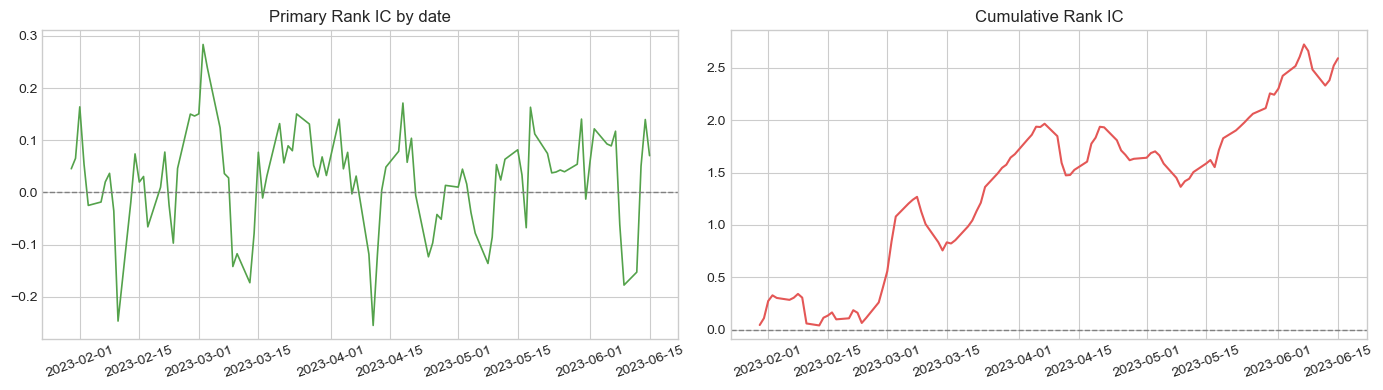


#### 📌 IC 解读
- **这一步在检验什么**：检查因子排序和未来收益排序是否稳定同向，这是判断单因子有没有横截面预测力的第一关。
- **怎么看**：先看 mean IC 是否为正，再看胜率和 ICIR，最后看时间序列是否持续围绕正区间波动、累计曲线是否总体向上。
- **当前结果意味着什么**：主版本 size_neutral 在 forward_return_5d 上的 mean IC 为 0.0262，胜率为 68.69%，ICIR 为 0.2713。如果 cumulative IC 向上，说明信号方向整体是对的。
- **有什么风险**：IC 容易被样本筛选、极端值处理和标签定义影响。尤其在真实数据里，若换一个 forward 口径就明显变脸，要优先回查交易时点和复权处理。


In [8]:
ic_display = ic_summary.copy()
ic_display['factor_version'] = ic_display['factor_version'].map(VERSION_LABELS)
display(ic_display)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
if primary_ic.empty:
    axes[0].text(0.5, 0.5, 'No IC sample', ha='center', va='center')
    axes[1].text(0.5, 0.5, 'No IC sample', ha='center', va='center')
else:
    x = pd.to_datetime(primary_ic['trade_date'])
    axes[0].plot(x, primary_ic['rank_ic'], color='#54a24b', linewidth=1.2)
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[0].set_title('Primary Rank IC by date')
    axes[0].tick_params(axis='x', rotation=20)

    axes[1].plot(x, primary_ic['cum_ic'], color='#e45756', linewidth=1.5)
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[1].set_title('Cumulative Rank IC')
    axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

if primary_ic.empty:
    current_text = '当前还没有足够样本计算主版本 IC，通常是历史长度或未来收益窗口不够。'
else:
    ic_row = ic_summary[
        (ic_summary['factor_version'] == PRIMARY_FACTOR)
        & (ic_summary['forward_horizon'] == PRIMARY_FORWARD)
    ].iloc[0]
    current_text = f"主版本 {VERSION_LABELS[PRIMARY_FACTOR]} 在 {PRIMARY_FORWARD} 上的 mean IC 为 {ic_row['mean']:.4f}，胜率为 {ic_row['win_rate']:.2%}，ICIR 为 {ic_row['ic_ir']:.4f}。如果 cumulative IC 向上，说明信号方向整体是对的。"

render_section_note(
    'IC 解读',
    '检查因子排序和未来收益排序是否稳定同向，这是判断单因子有没有横截面预测力的第一关。',
    '先看 mean IC 是否为正，再看胜率和 ICIR，最后看时间序列是否持续围绕正区间波动、累计曲线是否总体向上。',
    current_text,
    'IC 容易被样本筛选、极端值处理和标签定义影响。尤其在真实数据里，若换一个 forward 口径就明显变脸，要优先回查交易时点和复权处理。',
)

## 5. Quantile Return Analysis

这一节对应 Alphalens / jqfactor_analyzer 里最常见的“分层收益”视角。

我们把当日横截面按因子值切成 5 组，观察：

- 高分组未来收益是否系统性高于低分组。
- 组间收益是否具有单调性。
- 这种单调性是均值层面的，还是时间上也能积累出来。

如果 IC 是“排序相关性”证据，分层收益就是“经济解释”证据。

,quantile,mean_return,std_return,count,hit_rate
0,1,-0.0011,0.0120,99,0.4747
1,2,0.0012,0.0130,99,0.5758
2,3,-0.0012,0.0120,99,0.4141
3,4,-0.0001,0.0126,99,0.5354
4,5,0.0035,0.0130,99,0.5758


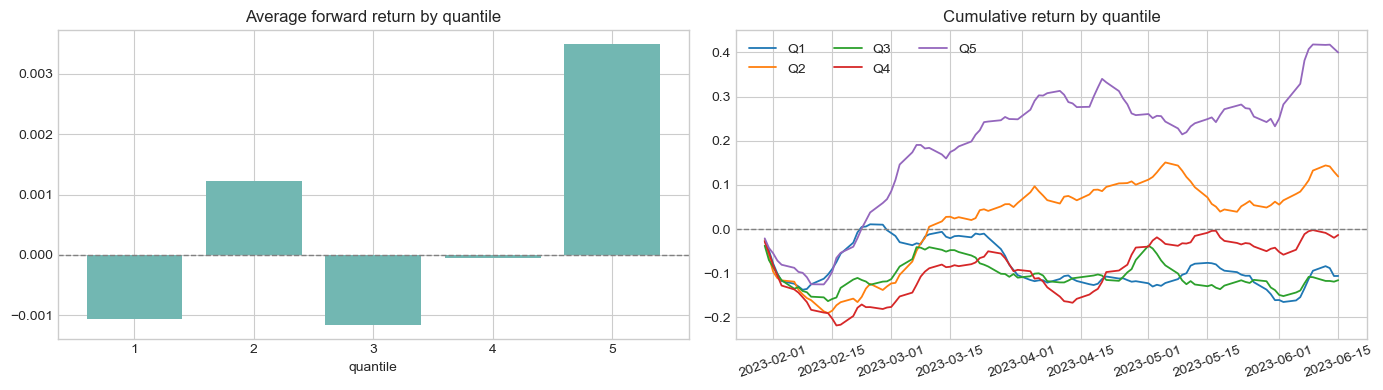


#### 📌 Quantile Return 解读
- **这一步在检验什么**：检验因子从低到高分组后，未来收益是否也从低到高分层展开。
- **怎么看**：先看 Q1 到 Q5 的平均收益柱状图，再看累计分层曲线是否拉开；两张图同时成立，分层证据会更扎实。
- **当前结果意味着什么**：Q1 到 Q5 的平均收益单调性表现 一般。如果 Q5 明显高于 Q1，且中间组次序也基本顺着走，说明因子不仅相关，而且能转成可解释的分层收益结构。
- **有什么风险**：分组收益容易受极端市场阶段影响。若只有 Q5 特别突出、但中间分组顺序很乱，说明因子更像尾部筛选器，而不是稳定的线性排序信号。


In [9]:
display(quantile_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
if quantile_summary.empty:
    axes[0].text(0.5, 0.5, 'No quantile sample', ha='center', va='center')
    axes[1].text(0.5, 0.5, 'No quantile sample', ha='center', va='center')
else:
    axes[0].bar(quantile_summary['quantile'].astype(str), quantile_summary['mean_return'], color='#72b7b2')
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[0].set_title('Average forward return by quantile')
    axes[0].set_xlabel('quantile')

    for bucket in quantile_cum.columns:
        axes[1].plot(pd.to_datetime(quantile_cum.index), quantile_cum[bucket], linewidth=1.3, label=f'Q{bucket}')
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[1].set_title('Cumulative return by quantile')
    axes[1].tick_params(axis='x', rotation=20)
    axes[1].legend(ncol=3)
plt.tight_layout()
plt.show()

if quantile_summary.empty:
    current_text = '当前还没有足够样本做分组收益分析。'
else:
    monotonic_hint = '较好' if quantile_summary['mean_return'].is_monotonic_increasing else '一般'
    current_text = f"Q1 到 Q5 的平均收益单调性表现 {monotonic_hint}。如果 Q5 明显高于 Q1，且中间组次序也基本顺着走，说明因子不仅相关，而且能转成可解释的分层收益结构。"

render_section_note(
    'Quantile Return 解读',
    '检验因子从低到高分组后，未来收益是否也从低到高分层展开。',
    '先看 Q1 到 Q5 的平均收益柱状图，再看累计分层曲线是否拉开；两张图同时成立，分层证据会更扎实。',
    current_text,
    '分组收益容易受极端市场阶段影响。若只有 Q5 特别突出、但中间分组顺序很乱，说明因子更像尾部筛选器，而不是稳定的线性排序信号。',
)

## 6. Long-short Analysis

这一节把前面的分层结果收敛成最直观的多空视角：`Q5 - Q1`。

这里不是正式策略回测，而是研究型多空收益观察。它回答的是：

- 如果做一个“高因子多、低因子空”的纸面组合，方向是否基本成立。
- 这个多空差值是偶尔有效，还是能逐步累积。
- 波动、回撤和胜率大概处在什么量级。

这一步能帮助我们判断因子是否值得进入下一轮更严格的策略验证。

,metric,value
0,mean_return,0.0045
1,volatility,0.0137
2,hit_rate,0.6364
3,cum_return,0.5527
4,max_drawdown,-0.1114


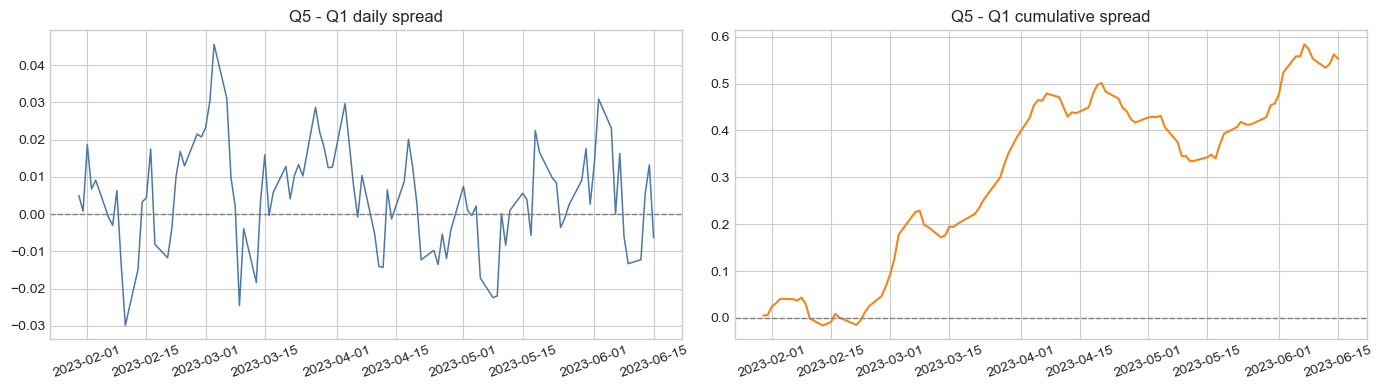


#### 📌 Long-short 解读
- **这一步在检验什么**：把分层收益浓缩成最直观的高分组减低分组，观察因子方向是否有稳定的纸面多空差。
- **怎么看**：先看 spread 均值和胜率，再看累计曲线是否持续向上，同时留意最大回撤不要过于极端。
- **当前结果意味着什么**：当前 Q5-Q1 的平均 5D spread 为 0.4548%，正收益占比为 63.64%，累计 spread 为 55.2671%。这可以看成因子方向是否值得继续深挖的研究型证据。
- **有什么风险**：这里仍然不是正式策略回测，没有交易成本、换手冲击、涨跌停和可融券约束，不能直接把累计多空收益理解成可实现收益。


In [10]:
display(long_short_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
if long_short.empty:
    axes[0].text(0.5, 0.5, 'No long-short sample', ha='center', va='center')
    axes[1].text(0.5, 0.5, 'No long-short sample', ha='center', va='center')
else:
    x = pd.to_datetime(long_short['trade_date'])
    axes[0].plot(x, long_short['long_short_return'], color='#4c78a8', linewidth=1.1)
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[0].set_title('Q5 - Q1 daily spread')
    axes[0].tick_params(axis='x', rotation=20)

    axes[1].plot(x, long_short['cum_return'], color='#f58518', linewidth=1.5)
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[1].set_title('Q5 - Q1 cumulative spread')
    axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

if long_short.empty:
    current_text = '当前还没有足够样本形成多空收益序列。'
else:
    ls_stats = long_short_stats.set_index('metric')['value']
    current_text = f"当前 Q5-Q1 的平均 5D spread 为 {ls_stats['mean_return']:.4%}，正收益占比为 {ls_stats['hit_rate']:.2%}，累计 spread 为 {ls_stats['cum_return']:.4%}。这可以看成因子方向是否值得继续深挖的研究型证据。"

render_section_note(
    'Long-short 解读',
    '把分层收益浓缩成最直观的高分组减低分组，观察因子方向是否有稳定的纸面多空差。',
    '先看 spread 均值和胜率，再看累计曲线是否持续向上，同时留意最大回撤不要过于极端。',
    current_text,
    '这里仍然不是正式策略回测，没有交易成本、换手冲击、涨跌停和可融券约束，不能直接把累计多空收益理解成可实现收益。',
)

## 7. Version Comparison: raw / zscore / size-neutral

这一节是报告里很重要的一步，因为它直接回答：

- 因子原始值有没有信息。
- 预处理后，信息是不是更稳定。
- 市值中性化到底是在“净化信号”，还是在“把信号洗没”。

如果 `size-neutral` 比 `raw` 和 `zscore` 更稳，通常说明原始因子里确实混入了一部分 size 暴露。

,factor_version,ic_mean,ic_win_rate,ic_ir,ls_mean,ls_hit_rate,ls_cum_return
0,raw,0.0207,0.6465,0.2192,0.0045,0.6263,0.5474
1,zscore,0.0207,0.6465,0.2194,0.0045,0.6263,0.5474
2,size_neutral,0.0262,0.6869,0.2713,0.0045,0.6364,0.5527


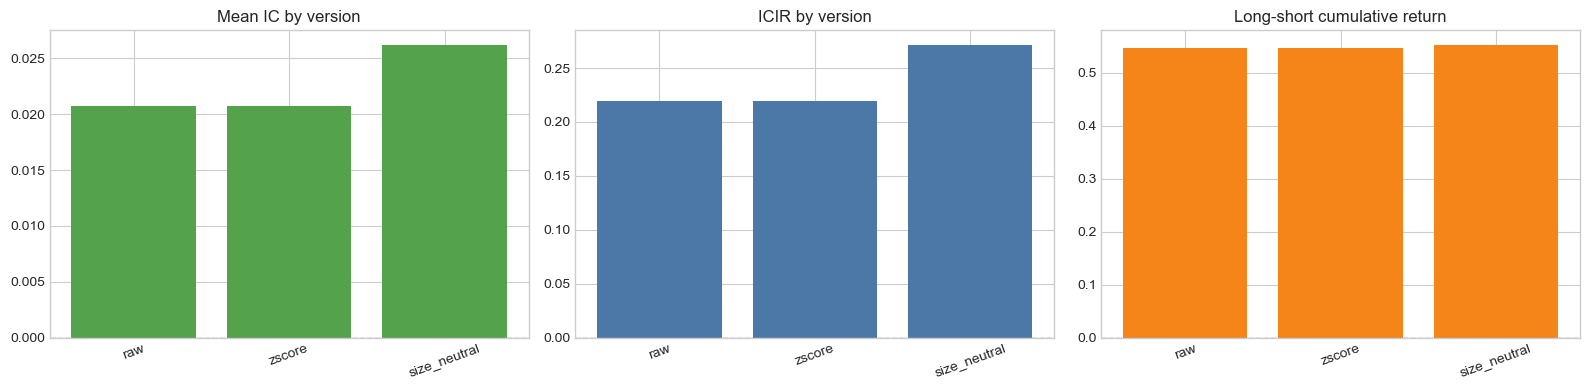


#### 📌 Version Comparison 解读
- **这一步在检验什么**：比较 raw、zscore、size-neutral 三个版本，判断预处理和中性化是否真的提升了研究信号质量。
- **怎么看**：重点看 mean IC、ICIR 和多空累计收益是否同步改善；如果只是某一个指标变好，要谨慎下结论。
- **当前结果意味着什么**：当前从 mean IC 看，表现最好的版本是 size_neutral。如果 size-neutral 在 IC 与 long-short 两边都不弱，通常可以优先把它当作主报告版本。
- **有什么风险**：版本对比依赖当前 mock 或样本窗口。真实数据里如果 raw 很强但 neutral 后明显变弱，需要分辨这是去掉了伪信号，还是把真正有效信息一起削掉了。


In [11]:
display(version_compare)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(version_compare['factor_version'], version_compare['ic_mean'], color='#54a24b')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Mean IC by version')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(version_compare['factor_version'], version_compare['ic_ir'], color='#4c78a8')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('ICIR by version')
axes[1].tick_params(axis='x', rotation=20)

axes[2].bar(version_compare['factor_version'], version_compare['ls_cum_return'], color='#f58518')
axes[2].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[2].set_title('Long-short cumulative return')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

best_ic_version = version_compare.sort_values('ic_mean', ascending=False).iloc[0]['factor_version'] if not version_compare.empty else 'N/A'
render_section_note(
    'Version Comparison 解读',
    '比较 raw、zscore、size-neutral 三个版本，判断预处理和中性化是否真的提升了研究信号质量。',
    '重点看 mean IC、ICIR 和多空累计收益是否同步改善；如果只是某一个指标变好，要谨慎下结论。',
    f"当前从 mean IC 看，表现最好的版本是 {best_ic_version}。如果 size-neutral 在 IC 与 long-short 两边都不弱，通常可以优先把它当作主报告版本。",
    '版本对比依赖当前 mock 或样本窗口。真实数据里如果 raw 很强但 neutral 后明显变弱，需要分辨这是去掉了伪信号，还是把真正有效信息一起削掉了。',
)

## 8. Stability Analysis

这一节补的是“能不能持续”这件事。

单因子研究里，稳定性至少要看三类东西：

- IC 前后半段是否一致。
- 因子自身序列是否过于跳跃。
- 分组换手是否太高。

如果一个因子均值还行，但稳定性很差，后面进策略层时通常会很痛苦。

,period,count,mean_ic,win_rate,ic_ir
0,full_sample,99,0.0262,0.6869,0.2726
1,first_half,49,0.0395,0.7143,0.4056
2,second_half,50,0.0131,0.6600,0.1414
3,last_20_obs,20,0.0438,0.8000,0.5173


,quantile,avg_turnover,median_turnover,count
0,1,0.2077,0.2222,98
1,2,0.4129,0.4118,98
2,3,0.4699,0.4706,98
3,4,0.4284,0.4375,98
4,5,0.1936,0.1875,98


,trade_date,autocorr,overlap_count
88,20230602,0.9661,83
89,20230605,0.9530,82
90,20230606,0.9488,81
91,20230607,0.9466,82
92,20230608,0.9500,82
93,20230609,0.9743,82
94,20230612,0.9548,83
95,20230613,0.9524,86
96,20230614,0.9670,85
97,20230615,0.9557,82


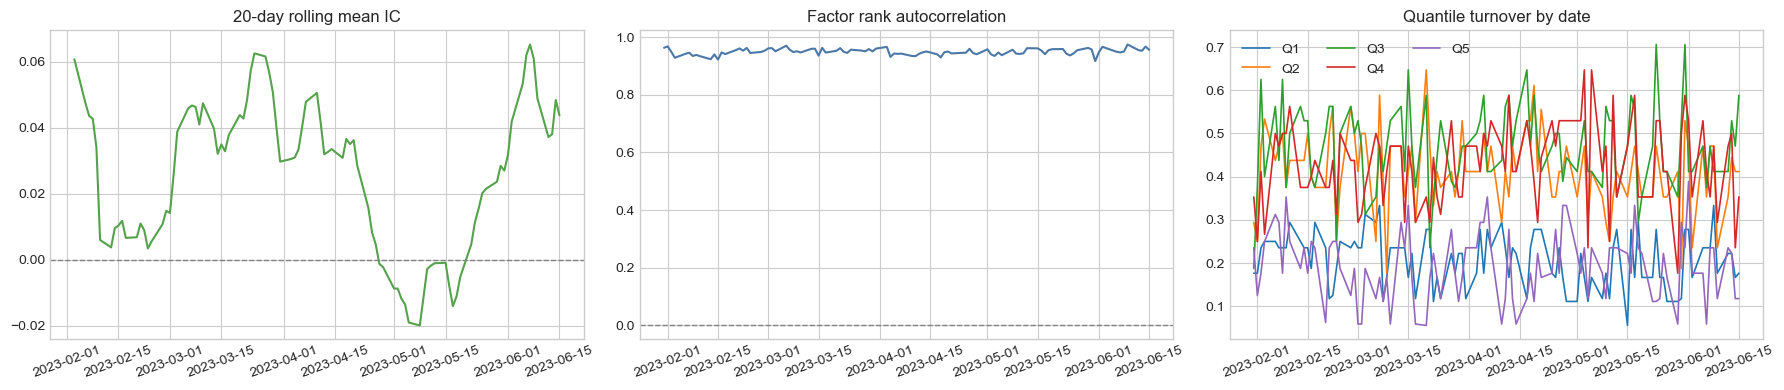


#### 📌 Stability 解读
- **这一步在检验什么**：检查因子表现是否前后段一致、因子值是否过于跳跃，以及分组成员是否换手过快。
- **怎么看**：先看 first_half / second_half 的 IC 是否同向，再看 rank autocorr 是否偏正，最后看 quantile turnover 是否高到难以承受。
- **当前结果意味着什么**：当前主因子的平均 rank autocorr 约为 0.9488，平均 quantile turnover 约为 34.25%。如果 IC 没塌、autocorr 为正、换手不过分，这个因子才算具备进入下一轮验证的稳定性基础。
- **有什么风险**：高稳定性不代表高收益，低换手也不一定是好事。若 autocorr 过高且 IC 很弱，可能只是一个变化很慢但没什么预测力的信号。


In [12]:
display(stability_table)
display(turnover_summary)
display(factor_autocorr.tail(10))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
if primary_ic.empty:
    axes[0].text(0.5, 0.5, 'No rolling IC sample', ha='center', va='center')
else:
    axes[0].plot(pd.to_datetime(primary_ic['trade_date']), primary_ic['rolling_mean_20'], color='#54a24b', linewidth=1.5)
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[0].set_title('20-day rolling mean IC')
    axes[0].tick_params(axis='x', rotation=20)

if factor_autocorr.empty:
    axes[1].text(0.5, 0.5, 'No autocorr sample', ha='center', va='center')
else:
    axes[1].plot(pd.to_datetime(factor_autocorr['trade_date']), factor_autocorr['autocorr'], color='#4c78a8', linewidth=1.5)
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
    axes[1].set_title('Factor rank autocorrelation')
    axes[1].tick_params(axis='x', rotation=20)

if turnover_daily.empty:
    axes[2].text(0.5, 0.5, 'No turnover sample', ha='center', va='center')
else:
    for bucket in sorted(turnover_daily['quantile'].unique()):
        part = turnover_daily[turnover_daily['quantile'] == bucket]
        axes[2].plot(pd.to_datetime(part['trade_date']), part['turnover'], linewidth=1.2, label=f'Q{bucket}')
    axes[2].set_title('Quantile turnover by date')
    axes[2].tick_params(axis='x', rotation=20)
    axes[2].legend(ncol=3)

plt.tight_layout()
plt.show()

mean_autocorr = factor_autocorr['autocorr'].mean() if not factor_autocorr.empty else np.nan
mean_turnover = turnover_summary['avg_turnover'].mean() if not turnover_summary.empty else np.nan
render_section_note(
    'Stability 解读',
    '检查因子表现是否前后段一致、因子值是否过于跳跃，以及分组成员是否换手过快。',
    '先看 first_half / second_half 的 IC 是否同向，再看 rank autocorr 是否偏正，最后看 quantile turnover 是否高到难以承受。',
    f"当前主因子的平均 rank autocorr 约为 {mean_autocorr:.4f}，平均 quantile turnover 约为 {mean_turnover:.2%}。如果 IC 没塌、autocorr 为正、换手不过分，这个因子才算具备进入下一轮验证的稳定性基础。",
    '高稳定性不代表高收益，低换手也不一定是好事。若 autocorr 过高且 IC 很弱，可能只是一个变化很慢但没什么预测力的信号。',
)

## 9. Final Interpretation

最后一节不是简单重复指标，而是把研究结论收成一句能拿去沟通的话：

- 这个因子现在更像“可继续研究”，还是“先别急着推进”。
- 主要证据来自哪几张表、哪几个图。
- 进入下一轮之前，最该补哪几个风险点。

这一步的目标，是把 Notebook 从“会算”变成“能判断”。

,question,status,comment
0,Data skeleton ready?,yes,Alphalens-like MultiIndex frame is available.
1,PIT risk controlled?,pending,Mock mode only; real PIT audit still pending.
2,IC positive?,yes,Use primary factor version and primary forward...
3,Quantile monotonic?,mixed,Judge together with cumulative quantile curves.
4,Long-short direction valid?,yes,"Research spread only, not a formal backtest."
5,Stability acceptable?,yes,"Need to combine IC, autocorr and turnover toge..."


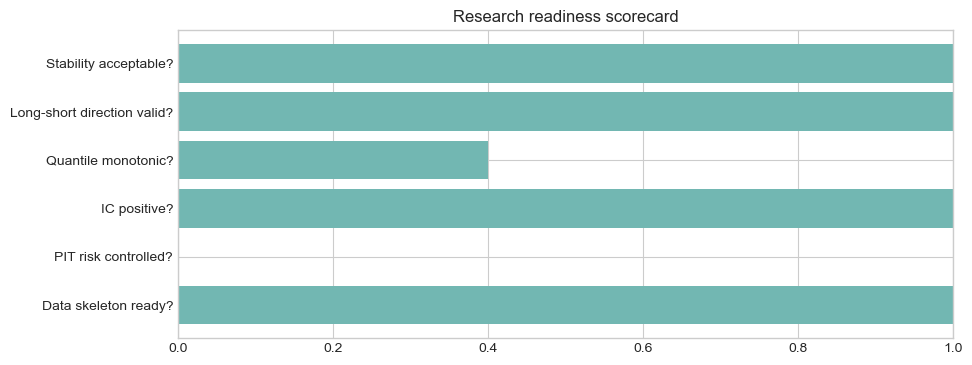


#### 📌 Final Interpretation
- **这一步在检验什么**：把前面各模块的证据汇总成一个可沟通的判断，而不是只报零散指标。
- **怎么看**：优先综合看 IC、分层收益、多空方向和稳定性，再把 PIT 风险单独拎出来，不让“看起来有效”掩盖“可能不干净”。
- **当前结果意味着什么**：当前结果更像“可以继续研究”的单因子，而不是“已经可以上策略”的单因子。下一步应切到真实数据并先完成 PIT 复核。
- **有什么风险**：这份结论仍建立在 mock 数据或有限真实样本上。正式推进前，至少还要补真实 PIT 审核、可交易口径、行业历史映射和回测层验证。


In [13]:
final_scorecard = pd.DataFrame(
    {
        'question': [
            'Data skeleton ready?',
            'PIT risk controlled?',
            'IC positive?',
            'Quantile monotonic?',
            'Long-short direction valid?',
            'Stability acceptable?',
        ],
        'status': [
            'yes' if len(alphalens_like) > 0 else 'no',
            'pending',
            'yes' if not primary_ic.empty and primary_ic['rank_ic'].mean() > 0 else 'weak',
            'yes' if not quantile_summary.empty and quantile_summary['mean_return'].is_monotonic_increasing else 'mixed',
            'yes' if not long_short.empty and long_short['long_short_return'].mean() > 0 else 'weak',
            'yes' if not stability_table.empty and stability_table['mean_ic'].dropna().min() > -0.02 else 'mixed',
        ],
        'comment': [
            'Alphalens-like MultiIndex frame is available.',
            'Mock mode only; real PIT audit still pending.',
            'Use primary factor version and primary forward horizon.',
            'Judge together with cumulative quantile curves.',
            'Research spread only, not a formal backtest.',
            'Need to combine IC, autocorr and turnover together.',
        ],
    }
)
display(final_scorecard)

score_map = {'yes': 1.0, 'mixed': 0.4, 'weak': 0.1, 'pending': 0.0, 'no': 0.0}
plot_score = final_scorecard.assign(score=final_scorecard['status'].map(score_map))

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(plot_score['question'], plot_score['score'], color='#72b7b2')
ax.set_xlim(0, 1)
ax.set_title('Research readiness scorecard')
plt.show()

if primary_ic.empty:
    verdict = '当前样本还不足以给出单因子结论，先补齐历史长度和 forward label。'
else:
    ic_row = ic_summary[
        (ic_summary['factor_version'] == PRIMARY_FACTOR)
        & (ic_summary['forward_horizon'] == PRIMARY_FORWARD)
    ].iloc[0]
    ls_stats = long_short_stats.set_index('metric')['value']
    if ic_row['mean'] > 0 and ls_stats['mean_return'] > 0:
        verdict = '当前结果更像“可以继续研究”的单因子，而不是“已经可以上策略”的单因子。下一步应切到真实数据并先完成 PIT 复核。'
    else:
        verdict = '当前结果说明这个因子的研究骨架已经搭好，但信号证据还不够强，建议先别推进正式策略验证。'

render_section_note(
    'Final Interpretation',
    '把前面各模块的证据汇总成一个可沟通的判断，而不是只报零散指标。',
    '优先综合看 IC、分层收益、多空方向和稳定性，再把 PIT 风险单独拎出来，不让“看起来有效”掩盖“可能不干净”。',
    verdict,
    '这份结论仍建立在 mock 数据或有限真实样本上。正式推进前，至少还要补真实 PIT 审核、可交易口径、行业历史映射和回测层验证。',
)

## 下一步

1. 把 `DATA_MODE` 从 `mock` 切到 `duckdb`，验证真实 `daily_panel` 能否直接产出同样的 9 段式报告。
2. 对 `close`、`adj_factor`、`market_cap`、`is_suspend`、`industry` 做真实 PIT 复核，尤其确认历史行业和复权链路。
3. 若真实数据下 IC / 分层 / 稳定性仍成立，再进入正式策略回测、交易约束和成本假设阶段。